In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.image as mpimg

# SVC VS SVR

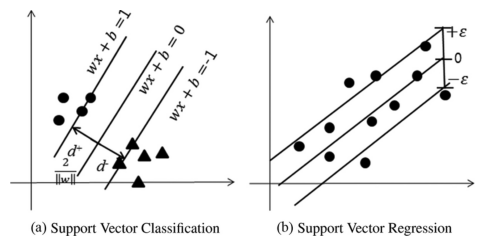

In [2]:
plt.figure(figsize=(6, 5))
img = mpimg.imread('Image/SVC and SVR.png')
plt.imshow(img)
plt.axis('off')
plt.show()

In [3]:
# In SVC we are Saperate Two Category
# We focus on all data stay in outside of the suport vecotor line
# In SVR we are focus on all data stay in inside the suport vector line
# in SVC we find longest distant prediction line
# in SVR we find shortest distant prediction line in where all data are comes
# in SVC that category comes inside Prediction line is called missclassifiar
# in SVR that category comes outside of prediction line called missclassifiar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('data/package.csv')

In [3]:
dataset.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


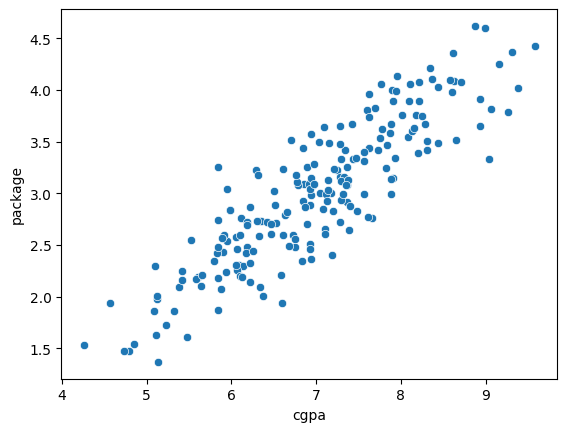

In [7]:
sns.scatterplot(data = dataset, x = "cgpa", y="package")
plt.show()

In [4]:
x = dataset[["cgpa"]]
y = dataset["package"]

In [5]:
from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.svm import SVR

In [17]:
sv = SVR(kernel='linear')
sv.fit(x_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [20]:
sv.score(x_test, y_test), sv.score(x_train, y_train)

(0.7706668029575103, 0.7745351616879739)

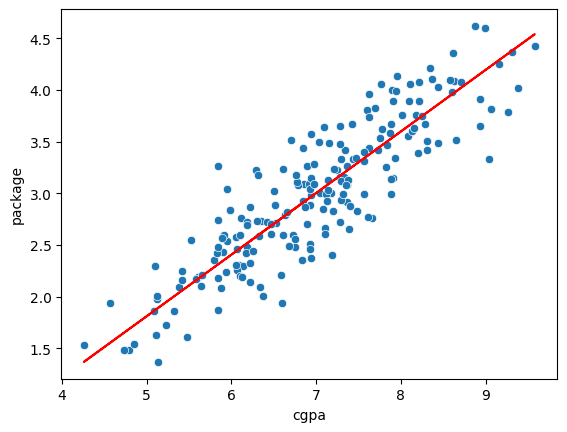

In [23]:
sns.scatterplot(x = dataset["cgpa"], y = dataset["package"])
plt.plot(dataset["cgpa"], sv.predict(x), color = "red")
plt.show()

In [24]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

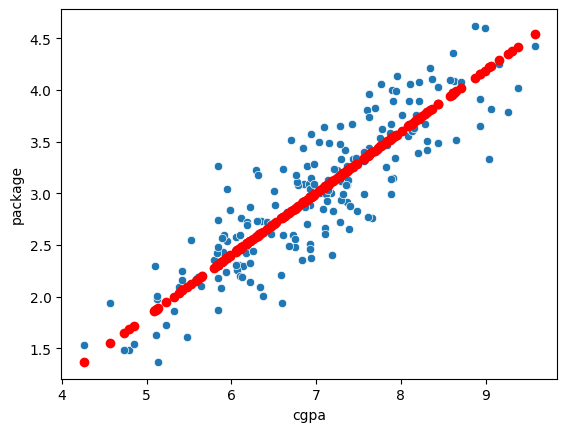

linear: 
 test score: 0.7706668029575103 
 train score: 0.7745351616879739 




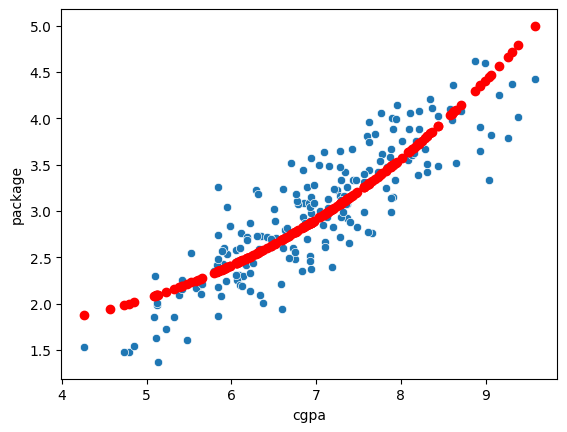

poly: 
 test score: 0.7230726378194225 
 train score: 0.7370560958175587 




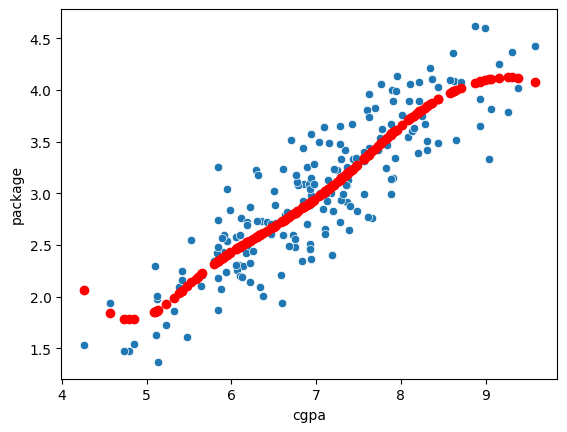

rbf: 
 test score: 0.7594945442913416 
 train score: 0.7816909319813372 




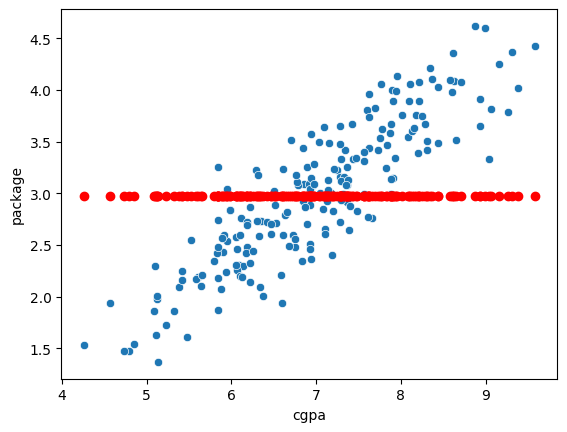

sigmoid: 
 test score: -0.0012751631607434977 
 train score: -0.0008676628025094946 




In [26]:
for kern in kernels:
    sv = SVR(kernel=kern)
    sv.fit(x_train, y_train)
    sns.scatterplot(x = dataset["cgpa"], y = dataset["package"])
    plt.scatter(dataset["cgpa"], sv.predict(x), color = "red")
    plt.show()
    print(f"{kern}: \n test score: {sv.score(x_test, y_test)} \n train score: {sv.score(x_train, y_train)} \n\n")

# What if data is not linearly separable